In [54]:
import seaborn as sns
import pandas as pd
import tabula
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np


# Exploring randomness in lottery drawings

Lottery drawings are designed to be random and impossible to predict. This notebook/project started out of mere curiosity about how trully random are lottery drawings in practice. To explore this question, I focus on Powerball, the largest and best-known lottery games in the United States, and examine how closely its observed number frequencies match the uniform distributions expected from a fair random process.

## Powerball format

Each Powerball drawing produces five distinct white-ball numbers selected without replacement from one pool and one red Powerball number selected from a separate pool. In the current format, the white-ball range is `1–69` and the red-ball range is `1–26`, but the range has varied historcally.

`Power Play` is a separately generated multiplier and does not affect which white or red numbers are selected. It is therefore excluded from the number-frequency analysis. `Double Play` uses the same white- and red-ball ranges but is a separate drawing, so its results are analyzed independently from the main Powerball results. Because the allowable number ranges have changed historically, drawings from different game formats are also analyzed separately.

The historical drawing results used in this analysis are available from the [Florida Lottery Powerball history](https://files.floridalottery.com/exptkt/pb.pdf).

# Data cleaning and sanitation

In [4]:
# fetch the latest updated data
!curl https://files.floridalottery.com/exptkt/pb.pdf -o pb.pdf

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
100 729.1k 100 729.1k   0      0  1.16M      0                              0


In [5]:
# ignore first page ==> additional content creates a parsing problems
df_lst_raw = tabula.read_pdf("pb.pdf", pages="2-90")

In [6]:
l = len(df_lst_raw)
print(l)

178


Why are there 178 elements instad of just 89?

In [7]:
df_lst_raw[0].head()

,Draw Date,Winning Numbers,Game,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,7/22/26,4,5,22,50,58,PB 1,X3,POWERBALL
1,7/22/26,9,51,54,60,61,PB 15,NaN,POWERBALL DP
2,7/20/26,2,9,44,53,59,PB 8,X2,POWERBALL
3,7/20/26,15,21,39,54,67,PB 7,NaN,POWERBALL DP
4,7/18/26,9,14,44,50,56,PB 3,X4,POWERBALL


In [8]:
df_lst_raw[1]

,Pages2/91


Thats it! `tabula` is reading the page numbers as separate table. Those can be easily excluded by filtering out using the column name

In [9]:
df = df_lst_raw[0]
for _df in  df_lst_raw[2:]:
    if not any("Pages" in c for c in _df.columns):
        df = pd.concat([df, _df], axis=0, ignore_index=True)

In [10]:
df.head()

,Draw Date,Winning Numbers,Game,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,7/22/26,4,5,22,50,58,PB 1,X3,POWERBALL
1,7/22/26,9,51,54,60,61,PB 15,NaN,POWERBALL DP
2,7/20/26,2,9,44,53,59,PB 8,X2,POWERBALL
3,7/20/26,15,21,39,54,67,PB 7,NaN,POWERBALL DP
4,7/18/26,9,14,44,50,56,PB 3,X4,POWERBALL


The column names are all messed up, lets fix them.

In [11]:
df = df.rename(columns = {"Draw Date": "date",
                     "Winning Numbers": "white_ball_1",
                     "Game": "white_ball_2",
                     "Unnamed: 0": "white_ball_3",
                     "Unnamed: 1": "white_ball_4",
                     "Unnamed: 2": "white_ball_5",
                     "Unnamed: 3": "red_ball", # Power Ball number
                     "Unnamed: 4": "pp_mult",  # Power Play multiplier
                     "Unnamed: 5": "game"})

In [12]:
df.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
0,7/22/26,4,5,22,50,58,PB 1,X3,POWERBALL
1,7/22/26,9,51,54,60,61,PB 15,NaN,POWERBALL DP
2,7/20/26,2,9,44,53,59,PB 8,X2,POWERBALL
3,7/20/26,15,21,39,54,67,PB 7,NaN,POWERBALL DP
4,7/18/26,9,14,44,50,56,PB 3,X4,POWERBALL


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          2848 non-null   str  
 1   white_ball_1  2848 non-null   int64
 2   white_ball_2  2848 non-null   int64
 3   white_ball_3  2848 non-null   int64
 4   white_ball_4  2848 non-null   int64
 5   white_ball_5  2848 non-null   int64
 6   red_ball      2848 non-null   str  
 7   pp_mult       2078 non-null   str  
 8   game          2848 non-null   str  
dtypes: int64(5), str(4)
memory usage: 200.4 KB


Much better, but there's still some problemns. The `pb` and `pp` columns are `str` type and need to be `int`. Before they can be casted, the additinal characters (PB, X) must be removed from each column. The date is also a `str`, so needs to be converted to a date type if date operation are needed.

In [14]:
df['red_ball'] = df['red_ball'].str.replace('PB ', '', regex=False)
df['pp_mult'] = df['pp_mult'].str.replace('X', '', regex=False)

In [15]:
df['red_ball'] = df['red_ball'].astype(int)
# the astype method cannot be used directly with the pp column since it contain NaN strings which cannot be
# casted to int directly. Instead we use the to_numeric method with the "coerce" option which forces the casting
# on the valid elements but asigns NaN to the unvalid ones.
df['pp_mult'] = pd.to_numeric(df['pp_mult'], errors="coerce").astype("Int64")
df["date"] = pd.to_datetime(df["date"])

/tmp/ipykernel_538056/528970629.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


In [16]:
df.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
0,2026-07-22,4,5,22,50,58,1,3,POWERBALL
1,2026-07-22,9,51,54,60,61,15,<NA>,POWERBALL DP
2,2026-07-20,2,9,44,53,59,8,2,POWERBALL
3,2026-07-20,15,21,39,54,67,7,<NA>,POWERBALL DP
4,2026-07-18,9,14,44,50,56,3,4,POWERBALL


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          2848 non-null   datetime64[us]
 1   white_ball_1  2848 non-null   int64         
 2   white_ball_2  2848 non-null   int64         
 3   white_ball_3  2848 non-null   int64         
 4   white_ball_4  2848 non-null   int64         
 5   white_ball_5  2848 non-null   int64         
 6   red_ball      2848 non-null   int64         
 7   pp_mult       2078 non-null   Int64         
 8   game          2848 non-null   str           
dtypes: Int64(1), datetime64[us](1), int64(6), str(1)
memory usage: 203.2 KB


Data looks good now, so we can go ahead and save the cleaned version to disk.

In [25]:
df.to_csv("powerball_numbers_cleaned.csv", index=False)

## Consistency Checks

In the powerball drawing, the number of the 5 white balls should be in the range `[1-69]`. The red ball (power ball) numbers should be in the range `[1-26]`

In [26]:
assert df[[f"white_ball_{x}" for x in range(1,6)]].min(axis=None) >= 1,  "White ball numbers out of range!"
assert df[[f"white_ball_{x}" for x in range(1,6)]].max(axis=None) <= 69, "White ball numbers out of range!"

In [27]:
assert df["red_ball"].min(axis=None) >= 1,  "Red (Power) ball numbers out of range!"
assert df["red_ball"].max(axis=None) <= 26, "Red (Power) ball numbers out of range!"

AssertionError: Red (Power) ball numbers out of range!

In [28]:
df["red_ball"].max(axis=None)

np.int64(39)

But why? Turns out there have been several versions of the powerball with different ball numbering ranges. Seven versions in total to be precise. The availbale data starts on January 7, 2009 and cover the last three versions: versions 5, 6 and 7 (the current version).

|version  |  start date  | end date   | white ball range  | red ball range |
|---------|------------- |------------|-------------------|-----------------
|5        | 2009-01-07   | 2012-01-14 |  1-59             | 1-39           |
|6        | 2012-01-18   | 2015-10-03 |  1-59             | 1-35           |
|7        | 2015-10-07   | present    |  1-69             | 1-26           |

The dataset must be split into these cases to avoid skewing the statistical results

In [29]:
df_v5 = df[ (df["date"] >= "2009-01-07") & (df["date"] <= "2012-01-14")]
assert df_v5["red_ball"].max(axis=None) == 39, "Power ball numbers out of range!"
df_v5.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
2542,2012-01-14,10,30,36,38,41,1,5,POWERBALL
2543,2012-01-11,5,19,29,45,47,25,2,POWERBALL
2544,2012-01-07,3,21,24,38,39,24,5,POWERBALL
2545,2012-01-04,21,35,46,47,50,2,4,POWERBALL
2546,2011-12-31,5,23,25,28,40,34,4,POWERBALL


In [30]:
df_v6 = df[ (df["date"] >= "2012-01-18") & (df["date"] <= "2015-10-03")]
assert df_v6["red_ball"].max(axis=None) == 35, "Power ball numbers out of range!"
df_v6.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
2154,2015-10-03,6,26,33,44,46,4,2,POWERBALL
2155,2015-09-30,21,39,40,55,59,17,3,POWERBALL
2156,2015-09-26,23,31,42,50,57,5,3,POWERBALL
2157,2015-09-23,8,29,41,51,58,5,2,POWERBALL
2158,2015-09-19,12,17,26,43,48,24,2,POWERBALL


In [31]:
df_v7 = df[df["date"] >= "2015-10-07"]
assert df_v7["red_ball"].max(axis=None) == 26, "Power ball numbers out of range!"
df_v7.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
0,2026-07-22,4,5,22,50,58,1,3,POWERBALL
1,2026-07-22,9,51,54,60,61,15,<NA>,POWERBALL DP
2,2026-07-20,2,9,44,53,59,8,2,POWERBALL
3,2026-07-20,15,21,39,54,67,7,<NA>,POWERBALL DP
4,2026-07-18,9,14,44,50,56,3,4,POWERBALL


In [32]:
df_v7["game"].unique().tolist()

['POWERBALL', 'POWERBALL DP']

Note that `v7` has two different values in the `game` column: `POWERBALL` and `POWERBALL DP`. The former is the plain old powerball draw while the latter refers to the douple play (hence DP) draw. The double play draw was introduced in August 23, 2021. Note that this falls within version 7 so thats why `POWERBALL DP` is missing from the other dataframes. Lets confirm this to make sure we split the data correctly.

In [33]:
print("Unique games in v5:", df_v5["game"].unique().tolist())
print("Unique games in v6:",df_v6["game"].unique().tolist())
print("Earliest date of POWERBALL DP in v7:", df_v7[df_v7["game"] == "POWERBALL DP"]["date"].min())

Unique games in v5: ['POWERBALL']
Unique games in v6: ['POWERBALL']
Earliest date of POWERBALL DP in v7: 2021-08-23 00:00:00


The earliest occurence of a `POWERBALL DP` value in the `game` column of `v7` matches our expectation of August 23, 2021. To avoid mixing things up, lets further split the `v7` data based on the game column.

In [34]:
df_v7_pb = df_v7[ df_v7["game"] == "POWERBALL" ]
df_v7_dp = df_v7[ df_v7["game"] == "POWERBALL DP" ]

In [35]:
df_v7_pb.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
0,2026-07-22,4,5,22,50,58,1,3,POWERBALL
2,2026-07-20,2,9,44,53,59,8,2,POWERBALL
4,2026-07-18,9,14,44,50,56,3,4,POWERBALL
6,2026-07-15,2,7,18,29,38,16,2,POWERBALL
8,2026-07-13,5,25,36,40,48,3,2,POWERBALL


In [36]:
df_v7_dp.head()

,date,white_ball_1,white_ball_2,white_ball_3,white_ball_4,white_ball_5,red_ball,pp_mult,game
1,2026-07-22,9,51,54,60,61,15,<NA>,POWERBALL DP
3,2026-07-20,15,21,39,54,67,7,<NA>,POWERBALL DP
5,2026-07-18,5,11,25,26,64,11,<NA>,POWERBALL DP
7,2026-07-15,14,15,23,33,42,16,<NA>,POWERBALL DP
9,2026-07-13,1,17,31,39,43,22,<NA>,POWERBALL DP


This concludes the data preparation step.

# Statistical Analysis

To begin, lets take a look at the frequency distribution of the white and red balls for each version of the drawing separately.


In [38]:
white_ball_cols = ["white_ball_1","white_ball_2", "white_ball_3", "white_ball_4", "white_ball_5"]

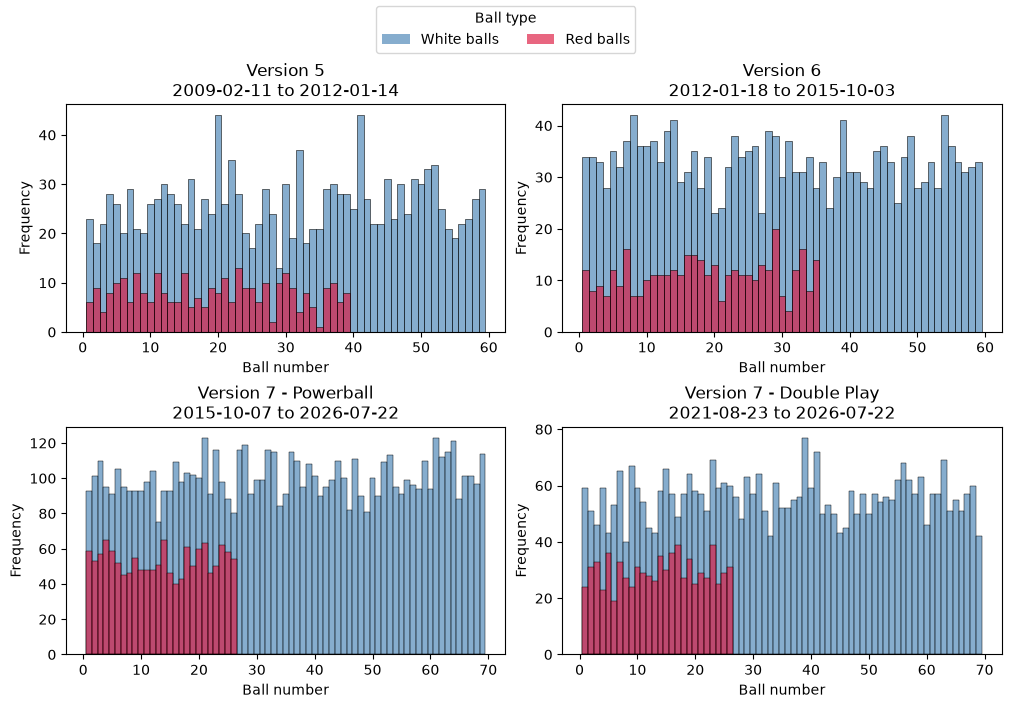

In [64]:
fig, axes = plt.subplots(2,2,figsize=(10, 7),layout="constrained")

white_color = "steelblue"
red_color = "crimson"

groups = [
            (axes[0, 0], df_v5,    "Version 5"),
            (axes[0, 1], df_v6,    "Version 6"),
            (axes[1, 0], df_v7_pb, "Version 7 - Powerball"),
            (axes[1, 1], df_v7_dp, "Version 7 - Double Play"),
]

for ax, data, name in groups:
    # White-ball frequency distribution
    sns.histplot(
                data[white_ball_cols].to_numpy().flatten(),
                stat="count",
                discrete=True,
                color=white_color,
                alpha=0.65,
                ax=ax
                )

    # Red-ball frequency distribution
    sns.histplot(
                data["red_ball"],
                stat="count",
                discrete=True,
                color=red_color,
                alpha=0.65,
                ax=ax
                )

    # Format the minimum and maximum dates for the subplot title.
    start_date = data["date"].min().strftime("%Y-%m-%d")
    end_date = data["date"].max().strftime("%Y-%m-%d")

    ax.set_title(f"{name}\n{start_date} to {end_date}")
    ax.set_xlabel("Ball number")
    ax.set_ylabel("Frequency")

# Proxy patches create one shared legend for the entire figure.
legend_handles = [ Patch(facecolor=white_color, alpha=0.65, label="White balls"),
                   Patch(facecolor=red_color, alpha=0.65, label="Red balls")
                 ]

fig.legend(
            handles=legend_handles,
            loc="outside upper center",
            ncols=2,
            title="Ball type"
            )

plt.show()

The Version 7 histograms appear reasonably uniform by visual inspection, whereas the Version 5 and Version 6 distributions show more noticeable variation. This apparent difference can likely be explained, at least in part, by sample size. Versions 5 and 6 contain considerably fewer drawings than Version 7, so their observed frequencies are expected to fluctuate more strongly.

In [129]:
print(f"Version 5 drawings: {len(df_v5)}")
print(f"Version 6 drawings: {len(df_v6)}")
print(f"Version 7 - Powerball drawings: {len(df_v7_pb)}")
print(f"Version 7 - Powerball drawings: {len(df_v7_dp)}")

Version 5 drawings: 306
Version 6 drawings: 388
Version 7 - Powerball drawings: 1384
Version 7 - Powerball drawings: 770


### Monte Carlo goodness-of-fit procedure

Each drawing regime and ball type is analyzed separately. The observed results are converted into a frequency vector,

$$
\mathbf{O} = (O_1, O_2, \ldots, O_N),
$$

where $O_i$ is the number of times ball $i$ appeared and $N$ is the number of possible ball numbers.

For a dataset containing $D$ drawings, the expected count for each red-ball number under a uniform distribution is

$$
E_{\mathrm{red}} = \frac{D}{N}.
$$

Because each drawing contains five white balls, the expected count for each white-ball number is

$$
E_{\mathrm{white}} = \frac{5D}{N}.
$$

The difference between the observed and expected frequencies is summarized using the Pearson discrepancy statistic,

$$
\chi^2_{\mathrm{obs}}=
\sum_{i=1}^{N}
\frac{(O_i-E_i)^2}{E_i},
$$

where $E_i$ is the appropriate expected count for the ball type being analyzed. A larger value of $\chi^2_{\mathrm{obs}}$ indicates a greater overall departure from uniformity.

For each Monte Carlo resample, a complete fair dataset containing the same number of drawings as the observed dataset is generated. A red-ball simulation selects one number uniformly from the allowed range in every drawing. A white-ball simulation selects five unique numbers without replacement in every drawing, preserving the dependence among the five selected balls.

The simulated drawings are converted into frequency counts, and the same statistic is calculated. Repeating this process $B=10000$ times produces the simulated statistics

$$
\chi^2_1, \chi^2_2, \ldots, \chi^2_B.
$$

Let $b$ be the number of simulations for which

$$
\chi^2_j \geq \chi^2_{\mathrm{obs}}.
$$

The Monte Carlo p-value is then

$$
p_{\mathrm{MC}}=
\frac{b+1}{B+1}.
$$

A small p-value indicates that few fair simulations were as uneven as the observed data and therefore provides evidence against uniformity. A large p-value indicates that the observed unevenness is reasonably common under fair random drawing; it does not prove that the distribution is perfectly uniform.

This procedure automatically accounts for differences in sample size and number range among the drawing regimes. It is particularly useful for the white balls because their selection without replacement violates the independence assumption of the ordinary Pearson chi-square test. Because eight distributions are analyzed, the resulting p-values are subsequently adjusted using the Holm procedure.


Fortunately, `scipy.stats` provides the `monte_carlo_test` function, which automates the resampling procedure, constructs the null distribution of the statistic, and calculates the Monte Carlo p-value. The observed frequency vector is supplied through the data argument, while custom functions specify how fair lottery datasets are generated and how the Pearson discrepancy statistic is calculated.


In [115]:
def compute_chi_square(observed_counts, axis=-1):
    """
    Observed counts:
        shape = (n_possible,)

    Simulated counts:
        shape = (batch_size, n_possible)
    """
    # keepdims = True needed to make it broadcastable in batch calculations
    total_count = observed_counts.sum(axis=axis, keepdims=True)
    n_categories = observed_counts.shape[axis]
    expected_count = total_count / n_categories
    return np.sum((observed_counts - expected_count) ** 2 / expected_count, axis=axis)


def make_fair_draws_generator( n_draws,
                                n_possible,
                                balls_per_draw,
                                rng):
    """
    Factory that creates a fair-count generator configured
    for one Powerball distribution.

    Parameters
    ----------
    n_draws:
        Number of drawings in each simulated dataset.

    n_possible:
        Number of possible ball numbers.

    balls_per_draw:
        Number of balls selected in each drawing:
            1 for red balls
            5 for white balls

    rng:
        NumPy random-number generator.

    Returns
    -------
    generate_fair_counts:
        Function with the rvs(size) interface required by
        scipy.stats.monte_carlo_test.
    """

    if n_draws <= 0:
        raise ValueError("n_draws must be positive.")

    if n_possible <= 0:
        raise ValueError("n_possible must be positive.")

    if not 1 <= balls_per_draw <= n_possible:
        raise ValueError(
            "balls_per_draw must be between 1 and n_possible."
        )
    

    def generate_fair_counts(size):
        """
        Generate simulated count vectors.

        SciPy supplies size in the form:

            (number of simulations, number of categories)
        """

        n_simulations = size[0]

        if balls_per_draw == 1:
            # Generate aggregate counts from n_draws independent
            # red-ball drawings.
            uniform_probabilities = np.full(n_possible, 1/n_possible)
            # drawing one ball from n_draws draws 
            simulated_counts = rng.multinomial(n=n_draws,
                                               pvals=uniform_probabilities,
                                               size=n_simulations)

        else:
            # Generate n_draws selections without replacement
            # for every simulated dataset.
            simulated_draws = rng.multivariate_hypergeometric(colors = np.ones(n_possible, dtype=int),
                                                              nsample=balls_per_draw,
                                                              size=(n_simulations, n_draws))

            # Input shape:
            # (n_simulations, n_draws, n_possible)
            #
            # Output shape:
            # (n_simulations, n_possible)
            simulated_counts = simulated_draws.sum(axis=1)

        return simulated_counts

    return generate_fair_counts


def run_uniformity_test(data_frame,
                        ball_columns,
                        n_possible,
                        balls_per_draw,
                        rng,
                        n_samples = 10_000,
                        batch_size = 50):
    """
    Test whether one ball distribution is consistent with
    uniform random drawing.

    Red balls:
        balls_per_draw = 1

    White balls:
        balls_per_draw = 5
    """
    
    n_draws = len(data_frame)
    
    if n_draws == 0:
        raise ValueError("Empty dataset")

    # raw values
    observed_values = data_frame[ball_columns].to_numpy(dtype=int).flatten()

    observed_counts = np.bincount(observed_values, minlength = n_possible +1)[1:] # exclude zero

    make_fair_draws = make_fair_draws_generator( n_draws,
                                                 n_possible,
                                                 balls_per_draw,
                                                 rng)

    result = monte_carlo_test(data=observed_counts,
                               rvs=make_fair_draws,
                               statistic=compute_chi_square,
                               vectorized=True,
                               n_resamples=n_samples,
                               batch=batch_size,
                               alternative="greater")
    return result

In [126]:
# Each tuple contains:
# name, dataframe, white-ball maximum, red-ball maximum
datasets = [("v5", df_v5, 59, 39),
            ("v6", df_v6, 59, 35),
            ("v7_pb", df_v7_pb, 69, 26),
            ("v7_dp", df_v7_dp, 69, 26)]

result = { "draw_version":[],
           "ball_color":[], 
           "n_draws": [],
           "chi_sq": [],
           "p_value": [],}

for version, df, n_white, n_red in datasets:

    
    
    white_result = run_uniformity_test(df,
                                       white_ball_cols,
                                       n_white,
                                       balls_per_draw=5,
                                       rng=rng)
    result["draw_version"].append(version)
    result["n_draws"].append(len(df))
    result["ball_color"].append("white")
    result["p_value"].append(white_result.pvalue)
    result["chi_sq"].append(white_result.statistic)

    red_result = run_uniformity_test(df,
                                       "red_ball",
                                       n_red,
                                       balls_per_draw=1,
                                       rng=rng)
    result["draw_version"].append(version)
    result["n_draws"].append(len(df))
    result["ball_color"].append("red")
    result["p_value"].append(red_result.pvalue)
    result["chi_sq"].append(red_result.statistic)
                                   
result_df = pd.DataFrame(result)
result_df["p_value_adj"] = np.minimum(len(result_df)*result_df["p_value"], 1)

In [128]:
result_df

,draw_version,ball_color,n_draws,chi_sq,p_value,p_value_adj
0,v5,white,306,78.039216,0.013499,0.107989
1,v5,red,306,38.882353,0.429757,1.000000
2,v6,white,388,37.108247,0.968803,1.000000
3,v6,red,388,32.541237,0.532947,1.000000
4,v7_pb,white,1384,80.787861,0.068093,0.544746
5,v7_pb,red,1384,23.982659,0.512549,1.000000
6,v7_dp,white,770,71.063896,0.249375,1.000000
7,v7_dp,red,770,21.412987,0.673533,1.000000
